In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib as ta

In [2]:
def load_data(path):
    return pd.read_csv(path, index_col="datetime", parse_dates=True)

dbtc = load_data(path='../data/binance_BTC_USDT_2019_2026_1h.csv')
deth = load_data(path='../data/binance_ETH_USDT_2019_2026_1h.csv')

In [3]:
dbtc.head(2)

,open,high,low,close,volume
datetime,,,,,
2019-01-01 00:00:00,3701.23,3713.00,3689.88,3700.31,686.367420
2019-01-01 01:00:00,3700.20,3702.73,3684.22,3689.69,613.539115


In [4]:
deth.head(2)

,open,high,low,close,volume
datetime,,,,,
2019-01-01 00:00:00,131.45,132.22,131.01,131.82,12677.96176
2019-01-01 01:00:00,131.83,131.88,131.00,131.14,9541.84565


In [5]:
dbtc.describe()

,open,high,low,close,volume
count,63479.000000,63479.000000,63479.000000,63479.000000,63479.000000
mean,42699.271934,42867.954973,42522.625053,42700.292447,2825.006858
std,32406.093937,32503.551664,32305.162102,32405.891194,4144.766539
min,3366.630000,3386.970000,3349.920000,3366.410000,0.000000
25%,13027.935000,13086.210000,12958.285000,13028.605000,810.888220
50%,34574.610000,34763.340000,34360.000000,34574.610000,1507.538130
75%,63627.875000,63873.250000,63359.110000,63628.420000,3013.296935
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600


In [6]:
deth.describe()

,open,high,low,close,volume
count,63479.000000,63479.000000,63479.000000,63479.000000,63479.000000
mean,1897.728595,1907.883701,1886.892920,1897.759549,24837.964634
std,1276.511937,1283.064358,1269.451687,1276.493214,27451.665440
min,96.510000,103.040000,86.000000,96.620000,0.000000
25%,412.405000,414.365000,410.305000,412.500000,9348.407300
50%,1872.300000,1878.930000,1865.880000,1872.400000,16517.025900
75%,2933.175000,2946.200000,2920.000000,2933.175000,30061.156765
max,4935.010000,4956.780000,4897.310000,4935.000000,508838.404900


In [7]:
def plot_price(data):
    plt.plot(data)
    plt.title("Biểu đồ giá Close") 
    plt.xlabel("Thời gian")   
    plt.ylabel("Giá")         
    plt.grid(True)        
    plt.show() 

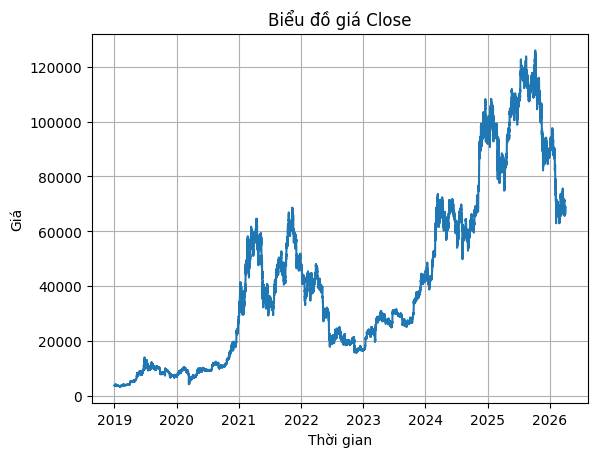

In [8]:
plot_price(dbtc.loc[:, "close"])

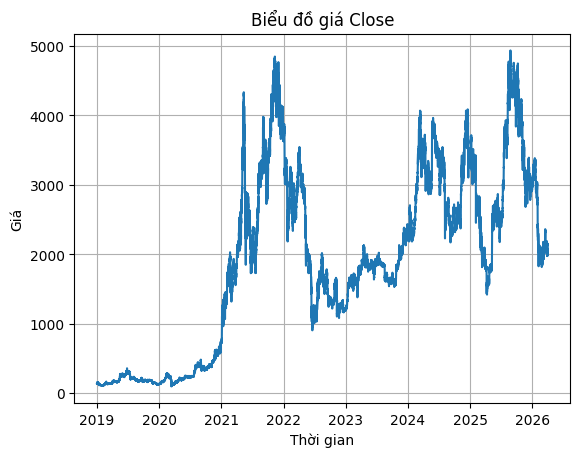

In [9]:
plot_price(deth.loc[:, "close"])

In [15]:
def pre_process(df):
    data = df.copy()
    EPSILON = 1e-8
    
    delta = data.index.to_series().diff()
    delta_time = delta.dt.total_seconds() / 3600
    delta_time = delta_time.fillna(1).astype(int)
    data['log_time_gap'] = np.log(delta_time)

    # 1. Temporal Features
    hours = data.index.hour
    day_of_week = data.index.dayofweek
    data['hour_sin'] = np.sin(2 * np.pi * hours / 24)
    data['hour_cos'] = np.cos(2 * np.pi * hours / 24)
    data['dow_sin'] = np.sin(2 * np.pi * day_of_week / 7)
    data['dow_cos'] = np.cos(2 * np.pi * day_of_week / 7)

    # 1. Price structure
    high_low_range = data['high'] - data['low'] + EPSILON
    data['body_ratio'] = (data['close'] - data['open']) / high_low_range
    max_open_close = data[['open', 'close']].max(axis=1)
    min_open_close = data[['open', 'close']].min(axis=1)
    data['upper_shadow_ratio'] = (data['high'] - max_open_close) / high_low_range
    data['lower_shadow_ratio'] = (min_open_close - data['low']) / high_low_range

    # 2. Multi-horizon Momentum
    horizons = [1, 4, 12, 24, 168]
    for h in horizons:
        data[f'log_ret_{h}'] = np.log(data['close'] / data['close'].shift(h))

    # 3. Volatility & Risk Representation
    data['volatility_4'] = data['log_ret_1'].rolling(window=4).std()
    
    volatility_horizons = [24, 168, 720]
    for h in volatility_horizons:
        data[f'volatility_{h}'] = data['log_ret_1'].rolling(window=h).std()
        data[f'volatility_{h}_ratio'] = data['volatility_4'] / (data[f'volatility_{h}'] + EPSILON)

    # Normalized Spread
    data['spread_hl_norm'] = np.log(data['high'] / (data['low'] + EPSILON)) / (data['volatility_4'] + EPSILON)

    # 4. Microstructure & Volume Dynamics
    typical_price = ta.TYPPRICE(data['high'], data['low'], data['close'])
    tp_vol = typical_price * data['volume']
    
    rolling_tp_vol = ta.SUM(tp_vol, timeperiod=24)
    rolling_vol = ta.SUM(data['volume'], timeperiod=24)
    
    vwap_24 = rolling_tp_vol / (rolling_vol + EPSILON)
    data['dist_vwap_24'] = (data['close'] - vwap_24) / (vwap_24 + EPSILON)

    # 5. Signed Volume Pressure
    direction = np.sign(data['log_ret_1'].fillna(0))
    log_signed_volume = np.log(1 + data['volume']) * direction

    window_z = 24
    mean_vol = ta.SMA(log_signed_volume, timeperiod=window_z)
    std_vol = ta.STDDEV(log_signed_volume, timeperiod=window_z, nbdev=1)

    data['signed_vol_pressure'] = (log_signed_volume - mean_vol) / (std_vol + EPSILON)

    data = data.loc[(data.index >= '2020-01-01') & (data.index <= '2026-03-31')]
    data = data.dropna()
    return data

In [11]:
pdbtc = pre_process(dbtc)
include = pdbtc.columns.to_list()
exclude = ["open", "high", "low", "close", "volume"]
include = [x if x not in exclude else '' for x in include]
k = []
for x in include:
    if x != '':
        k.append(x)
k
des = pdbtc.loc[:, k].describe()
des.to_csv('btc_statistics.csv')
des

,log_time_gap,hour_sin,hour_cos,dow_sin,dow_cos,body_ratio,upper_shadow_ratio,lower_shadow_ratio,log_ret_1,log_ret_4,...,volatility_4,volatility_24,volatility_24_ratio,volatility_168,volatility_168_ratio,volatility_720,volatility_720_ratio,spread_hl_norm,dist_vwap_24,signed_vol_pressure
count,54713.000000,54713.000000,5.471300e+04,54713.000000,54713.000000,54713.000000,54713.000000,54713.000000,54713.000000,54713.000000,...,54713.000000,54713.000000,54713.000000,54713.000000,54713.000000,54713.000000,54713.000000,5.471300e+04,54713.000000,54713.000000
mean,0.000291,-0.000192,-1.256821e-05,-0.000307,-0.000296,0.011608,0.276423,0.294779,0.000041,0.000163,...,0.004890,0.005538,0.895024,0.005921,0.831791,0.006140,0.807338,2.175047e+00,0.000967,-0.000135
std,0.018740,0.707096,7.071300e-01,0.707064,0.707163,0.496042,0.204012,0.210336,0.006671,0.013045,...,0.004609,0.003731,0.474302,0.003074,0.589285,0.002608,0.649582,1.748079e+00,0.015675,0.996295
min,0.000000,-1.000000,-1.000000e+00,-0.974928,-0.900969,-1.000000,0.000000,0.000000,-0.201033,-0.342863,...,0.000062,0.000455,0.017288,0.001510,0.016764,0.002361,0.013722,-5.104019e-10,-0.297458,-2.371253
25%,0.000000,-0.707107,-7.071068e-01,-0.781831,-0.900969,-0.408367,0.110222,0.122897,-0.002325,-0.004517,...,0.002145,0.003292,0.535953,0.004054,0.435900,0.004395,0.396404,1.274531e+00,-0.006255,-0.974256
50%,0.000000,0.000000,-1.836970e-16,0.000000,-0.222521,0.014132,0.240183,0.262393,0.000061,0.000172,...,0.003662,0.004799,0.812076,0.005246,0.682349,0.005609,0.639646,1.827881e+00,0.000695,0.606455
75%,0.000000,0.707107,7.071068e-01,0.781831,0.623490,0.432005,0.410228,0.437390,0.002504,0.005032,...,0.006163,0.006694,1.173852,0.006959,1.050007,0.007165,1.011618,2.577600e+00,0.007953,0.951406
max,1.791759,1.000000,1.000000e+00,0.974928,1.000000,1.000000,0.984800,0.999114,0.160280,0.182272,...,0.151467,0.077109,2.653328,0.036024,6.452215,0.019801,10.661449,1.164030e+02,0.107595,2.288555
